In [99]:
from langgraph.graph import START,END, StateGraph 
from typing import TypedDict
from langchain_groq import ChatGroq 
from dotenv import load_dotenv 
load_dotenv() 


True

In [100]:
llm=ChatGroq(model='Llama-3.3-70b-Versatile') 

llm2=ChatGroq(model='Llama-3.3-70b-Versatile')


In [101]:
llm.invoke('hi how are you translate in hindi').content

'"Hi, how are you?" can be translated to Hindi as:\n\n"नमस्ते, आप कैसे हैं?" (Namaste, aap kaise hain?)\n\nHere\'s a breakdown:\n\n* "Hi" is translated to "नमस्ते" (Namaste), which is a common Hindi greeting.\n* "How are you?" is translated to "आप कैसे हैं?" (Aap kaise hain?), where:\n\t+ "आप" (Aap) means "you".\n\t+ "कैसे" (Kaise) means "how".\n\t+ "हैं" (Hain) is a verb that means "are".\n\nSo, "नमस्ते, आप कैसे हैं?" (Namaste, aap kaise hain?) is a polite way to greet someone and ask about their well-being in Hindi.'

In [102]:
#here in this we need 2 different states for the different graphs 
class Main_state(TypedDict): 
    query: str 
    answer: str 
    translation: str 
    
class Sub_state(TypedDict):
    eng_text: str 
    hin_text: str 
    

In [103]:
main_graph=StateGraph(Main_state)

In [104]:
sub_graph=StateGraph(Sub_state) 


In [105]:
def translate(state: Sub_state)->Sub_state:
    eng_text=state['eng_text'] 
    input=f"""Please translate  the following text in hindi  \n\n
    
    
    english text --{eng_text}--
    
    
    
    
    Translation -- Your translation
    """
    
    
    
    response=llm2.invoke(input).content 
    return {'hin_text':response}
    

In [106]:
#lets build the sub graph 
sub_graph.add_node('translate',translate) 
sub_graph.add_edge(START,'translate') 
sub_graph.add_edge('translate',END) 

In [107]:
sub_workflow=sub_graph.compile()

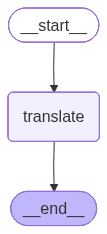

In [108]:
sub_workflow

In [109]:
# NODES FOR THE MAIN GRAPH
def chat_node(state: Main_state)-> Main_state: 
    q=state['query'] 
    response=llm.invoke(q).content 
    return {'answer':response}

def translation(state: Main_state)-> Main_state: 
    #here we will call the sub graph and take response from it 
    text=state['answer']
    initial_state={'eng_text':text} 
    final_state=sub_workflow.invoke(initial_state)
    hindi=final_state['hin_text']
    return {'translation':hindi}
    

In [110]:
#lets build the main graph
main_graph.add_node('chat_node',chat_node) 
main_graph.add_node('translation',translation)

main_graph.add_edge(START,'chat_node') 
main_graph.add_edge('chat_node','translation') 
main_graph.add_edge('translation',END) 

In [111]:
main_workflow=main_graph.compile()

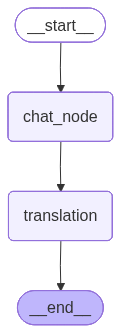

In [112]:
main_workflow

In [113]:
#now lets invoke our main_workflow and then check that it is working fine or not
initial_state={'query':'Create a blog for the biography of Ramanujan Ji'} 

final_state=main_workflow.invoke(initial_state)

In [114]:
final_state

{'query': 'Create a blog for the biography of Ramanujan Ji',
 'answer': '**The Extraordinary Life of Srinivasa Ramanujan: A Mathematical Genius**\n\nSrinivasa Ramanujan, widely regarded as one of the most brilliant mathematicians of the 20th century, left an indelible mark on the world of mathematics. Born on December 22, 1887, in Erode, Tamil Nadu, India, Ramanujan\'s life was a testament to the power of human ingenuity and the importance of perseverance in the face of adversity.\n\n**Early Life and Education**\n\nRamanujan was born to a traditional Indian family, where his father, K. Srinivasa Iyengar, was a shopkeeper, and his mother, Komalatammal, was a homemaker. From a young age, Ramanujan demonstrated a keen interest in mathematics, which was encouraged by his schoolteacher, Mrs. L. Manners. He attended the Town High School in Kumbakonam, where he excelled in mathematics, but struggled with other subjects.\n\nIn 1904, Ramanujan entered the Government College in Kumbakonam, where

In [115]:
from IPython.display import display,Markdown 
display(Markdown(final_state['answer'])) 

**The Extraordinary Life of Srinivasa Ramanujan: A Mathematical Genius**

Srinivasa Ramanujan, widely regarded as one of the most brilliant mathematicians of the 20th century, left an indelible mark on the world of mathematics. Born on December 22, 1887, in Erode, Tamil Nadu, India, Ramanujan's life was a testament to the power of human ingenuity and the importance of perseverance in the face of adversity.

**Early Life and Education**

Ramanujan was born to a traditional Indian family, where his father, K. Srinivasa Iyengar, was a shopkeeper, and his mother, Komalatammal, was a homemaker. From a young age, Ramanujan demonstrated a keen interest in mathematics, which was encouraged by his schoolteacher, Mrs. L. Manners. He attended the Town High School in Kumbakonam, where he excelled in mathematics, but struggled with other subjects.

In 1904, Ramanujan entered the Government College in Kumbakonam, where he was introduced to advanced mathematics by his professor, P. V. Seshu Iyer. However, due to his poor performance in other subjects, Ramanujan was forced to drop out of college. This setback did not deter him, and he continued to pursue his passion for mathematics, often working on complex problems and theorems in his spare time.

**The Discovery of Ramanujan**

In 1913, Ramanujan, then a 25-year-old clerk in the Madras Port Trust, sent a letter to the renowned mathematician, G. H. Hardy, at Cambridge University. The letter contained a list of 120 mathematical theorems and formulas, which left Hardy astonished. Recognizing the genius of Ramanujan, Hardy invited him to come to Cambridge to work with him.

Ramanujan arrived in Cambridge in 1914, and his collaboration with Hardy marked the beginning of a highly productive period in his life. Together, they worked on various mathematical projects, including the development of the Hardy-Ramanujan asymptotic formula for the number of partitions of an integer.

**Contributions to Mathematics**

Ramanujan's contributions to mathematics are too numerous to list, but some of his most notable achievements include:

* **Number Theory**: Ramanujan made significant contributions to number theory, including the development of the Hardy-Ramanujan asymptotic formula, which describes the distribution of prime numbers.
* **Modular Forms**: Ramanujan's work on modular forms, which are functions that satisfy certain symmetry properties, led to important advances in the field of algebraic geometry.
* **Elliptic Curves**: Ramanujan's research on elliptic curves, which are curves defined by cubic equations, led to a deeper understanding of the properties of these curves and their applications in number theory.

**Personal Life and Health**

Ramanujan's life was marked by personal struggles, including poverty, illness, and loneliness. He was a devout Hindu and a strict vegetarian, which often made it difficult for him to adjust to the Western diet and lifestyle in Cambridge. Despite these challenges, Ramanujan remained committed to his work and continued to produce groundbreaking research until his untimely death.

In 1917, Ramanujan contracted tuberculosis, which was a major health concern at the time. He returned to India in 1919, where he died on April 26, 1920, at the age of 32.

**Legacy**

Ramanujan's legacy extends far beyond his mathematical contributions. He is an inspiration to mathematicians and scientists around the world, and his story has been the subject of numerous books, films, and documentaries. The Ramanujan Institute for Advanced Study in Mathematics at the University of Madras, India, was established in his honor, and the Srinivasa Ramanujan Award is given annually to recognize outstanding contributions to mathematics.

In conclusion, Srinivasa Ramanujan's life was a testament to the power of human creativity and perseverance. His contributions to mathematics continue to inspire and influence researchers to this day, and his legacy serves as a reminder of the importance of supporting and nurturing talent, regardless of background or circumstance.

**Timeline of Ramanujan's Life**

* December 22, 1887: Born in Erode, Tamil Nadu, India
* 1904: Enters Government College in Kumbakonam
* 1913: Sends a letter to G. H. Hardy, containing a list of mathematical theorems and formulas
* 1914: Arrives in Cambridge to work with G. H. Hardy
* 1917: Contracts tuberculosis
* 1919: Returns to India
* April 26, 1920: Dies at the age of 32

**Recommended Reading**

* **"The Man Who Knew Infinity"** by Robert Kanigel: A biography of Ramanujan's life, which explores his mathematical contributions and personal struggles.
* **"Ramanujan: Twelve Lectures on Subjects Suggested by His Life and Work"** by G. H. Hardy: A collection of lectures delivered by Hardy, which provide insights into Ramanujan's mathematical contributions and their significance.
* **"Collected Papers of Srinivasa Ramanujan"**: A collection of Ramanujan's mathematical papers, which showcase his contributions to number theory, modular forms, and elliptic curves.

**Video Resources**

* **"The Man Who Knew Infinity" (2015)**: A biographical film about Ramanujan's life, starring Dev Patel and Jeremy Irons.
* **"Ramanujan: The Mathematician"**: A documentary series that explores Ramanujan's life and mathematical contributions.

I hope you enjoyed this blog on the biography of Srinivasa Ramanujan. Please let me know if you have any questions or if you'd like to learn more about this fascinating mathematician.

In [116]:
display(Markdown(final_state['translation']))

**श्रीनिवास रामानुजन: एक गणितीय प्रतिभा का असाधारण जीवन**

श्रीनिवास रामानुजन, जिन्हें 20वीं शताब्दी के सबसे प्रतिभाशाली गणितज्ञों में से एक माना जाता है, ने गणित की दुनिया पर एक अमिट छाप छोड़ी। उनका जन्म 22 दिसंबर, 1887 को तमिलनाडु, भारत के एरोड में हुआ था, और उनका जीवन मानव बुद्धिमत्ता और कठिनाइयों का सामना करने में दृढ़ता की शक्ति का प्रमाण है।

**प्रारंभिक जीवन और शिक्षा**

रामानुजन का जन्म एक पारंपरिक भारतीय परिवार में हुआ था, जहां उनके पिता, के. श्रीनिवास आयेंगर, एक दुकानदार थे, और उनकी माता, कोमलातम्मल, एक गृहिणी थीं। रामानुजन ने बचपन से ही गणित में रुचि दिखाई, जिसे उनकी स्कूल शिक्षिका, मिसेज़ एल. मैनर्स ने प्रोत्साहित किया। उन्होंने कुंभकोणम के टाउन हाई स्कूल में पढ़ाई की, जहां उन्होंने गणित में उत्कृष्टता हासिल की, लेकिन अन्य विषयों में संघर्ष किया।

1904 में, रामानुजन ने कुंभकोणम के सरकारी कॉलेज में प्रवेश लिया, जहां उन्हें प्रोफेसर पी.वी. सेशु अय्यर ने उच्च गणित से परिचित कराया। हालांकि, अन्य विषयों में उनके खराब प्रदर्शन के कारण, रामानुजन को कॉलेज छोड़ना पड़ा। यह सेटबैक उन्हें रोक नहीं पाया, और उन्होंने अपने जुनून के लिए गणित का पीछा करना जारी रखा, अक्सर जटिल समस्याओं और सिद्धांतों पर अपने खाली समय में काम किया।

**रामानुजन की खोज**

1913 में, रामानुजन, जो तब मद्रास पोर्ट ट्रस्ट में एक 25 वर्षीय क्लर्क थे, ने कैम्ब्रिज विश्वविद्यालय में प्रसिद्ध गणितज्ञ जी.एच. हार्डी को एक पत्र भेजा। पत्र में 120 गणितीय सिद्धांतों और सूत्रों की एक सूची थी, जिसने हार्डी को आश्चर्यचकित कर दिया। रामानुजन की प्रतिभा को पहचानते हुए, हार्डी ने उन्हें कैम्ब्रिज आने और उनके साथ काम करने के लिए आमंत्रित किया।

रामानुजन 1914 में कैम्ब्रिज पहुंचे, और उनका हार्डी के साथ सहयोग उनके जीवन की एक अत्यधिक उत्पादक अवधि की शुरुआत को चिह्नित किया। उन्होंने विभिन्न गणितीय परियोजनाओं पर काम किया, जिसमें हार्डी-रामानुजन एसिम्प्टोटिक फॉर्मूला का विकास शामिल था, जो एक पूर्णांक के विभाजन की संख्या का वर्णन करता है।

**गणित में योगदान**

रामानुजन के गणित में योगदान बहुत अधिक हैं, लेकिन उनकी कुछ सबसे उल्लेखनीय उपलब्धियों में शामिल हैं:

* **संख्या सिद्धांत**: रामानुजन ने संख्या सिद्धांत में महत्वपूर्ण योगदान दिया, जिसमें हार्डी-रामानुजन एसिम्प्टोटिक फॉर्मूला का विकास शामिल था, जो प्रधान संख्याओं के वितरण का वर्णन करता है।
* **मॉड्यूलर फॉर्म**: रामानुजन का मॉड्यूलर फॉर्म पर काम, जो कertain समरूपता गुणों को संतुष्ट करने वाले फंक्शन हैं, बीजगणितीय ज्यामिति के क्षेत्र में महत्वपूर्ण प्रगति के लिए नेतृत्व किया।
* **अण्डाकार वक्र**: रामानुजन का अण्डाकार वक्र पर शोध, जो घन समीकरणों द्वारा परिभाषित वक्र हैं, ने इन वक्रों के गुणों और संख्या सिद्धांत में उनके अनुप्रयोगों की गहरी समझ के लिए नेतृत्व किया।

**व्यक्तिगत जीवन और स्वास्थ्य**

रामानुजन का जीवन व्यक्तिगत संघर्षों से भरा हुआ था, जिसमें गरीबी, बीमारी और एकांत शामिल था। वह एक दृढ़ हिंदू और एक सख्त शाकाहारी थे, जो अक्सर कैम्ब्रिज में पश्चिमी आहार और जीवनशैली के लिए अनुकूलन करना मुश्किल बना देता था। इन चुनौतियों के बावजूद, रामानुजन ने अपने काम के प्रति अपनी प्रतिबद्धता बनाए रखी और अपनी अकाल मृत्यु तक ग्राउंडब्रेकिंग शोध जारी रखा।

1917 में, रामानुजन ने ट्यूबरकुलोसिस का संक्रमण किया, जो उस समय एक प्रमुख स्वास्थ्य चिंता थी। उन्होंने 1919 में भारत लौटे, जहां उन्होंने 26 अप्रैल, 1920 को 32 वर्ष की आयु में उनकी मृत्यु हो गई।

**विरासत**

रामानुजन की विरासत उनके गणितीय योगदान से बहुत आगे निकल जाती है। वह दुनिया भर के गणितज्ञों और वैज्ञानिकों के लिए एक प्रेरणा हैं, और उनकी कहानी कई पुस्तकों, फिल्मों और वृत्तचित्रों का विषय रही है। भारत के मद्रास विश्वविद्यालय में रामानुजन इंस्टीट्यूट फॉर एडवांस्ड स्टडी इन मैथमेटिक्स की स्थापना उनके सम्मान में की गई थी, और श्रीनिवास रामानुजन पुरस्कार प्रतिवर्ष गणित में उत्कृष्ट योगदान को मान्यता देने के लिए दिया जाता है।

निष्कर्ष में, श्रीनिवास रामानुजन का जीवन मानव रचनात्मकता और दृढ़ता की शक्ति का प्रमाण है। उनके गणितीय योगदान आज भी शोधकर्ताओं को प्रेरित और प्रभावित करते हैं, और उनकी विरासत प्रतिभा को समर्थन और पोषण देने के महत्व की याद दिलाती है, चाहे वह किसी भी पृष्ठभूमि या परिस्थिति से हो।

**रामानुजन के जीवन की समयरेखा**

* 22 दिसंबर, 1887: एरोड, तमिलनाडु, भारत में जन्म
* 1904: कुंभकोणम के सरकारी कॉलेज में प्रवेश
* 1913: जी.एच. हार्डी को एक पत्र भेजा, जिसमें गणितीय सिद्धांतों और सूत्रों की एक सूची शामिल थी
* 1914: कैम्ब्रिज में हार्डी के साथ काम करने के लिए पहुंचे
* 1917: ट्यूबरकुलोसिस का संक्रमण किया
* 1919: भारत लौटे
* 26 अप्रैल, 1920: 32 वर्ष की आयु में मृत्यु

**अनुशंसित पठन**

* **"द मैन हू न्यू इन्फिनिटी"** रॉबर्ट कानिगेल द्वारा: रामानुजन के जीवन की एक जीवनी, जो उनके गणितीय योगदान और व्यक्तिगत संघर्षों का अन्वेषण करती है।
* **"रामानुजन: ट्वेल्व लेक्चर्स ऑन सब्जेक्ट्स सजेस्टेड बाय हिस लाइफ एंड वर्क"** जी.एच. हार्डी द्वारा: हार्डी द्वारा दिए गए व्याख्यानों का एक संग्रह, जो रामानुजन के गणितीय योगदान और उनके महत्व के बारे में अंतर्दृष्टि प्रदान करते हैं।
* **"कलेक्टेड पेपर्स ऑफ श्रीनिवास रामानुजन"**: रामानुजन के गणितीय पत्रों का एक संग्रह, जो संख्या सिद्धांत, मॉड्यूलर फॉर्म और अण्डाकार वक्र में उनके योगदान को प्रदर्शित करता है।

**वीडियो संसाधन**

* **"द मैन हू न्यू इन्फिनिटी" (2015)**: रामानुजन के जीवन पर एक जीवनी फिल्म, जिसमें देव पटेल और जेरेमी आयरन्स ने अभिनय किया है।
* **"रामानुजन: द मैथमेटिशियन"**: रामानुजन के जीवन और गणितीय योगदान का अन्वेषण करने वाली एक वृत्तचित्र श्रृंखला।